# Basic System

This notebook provides code for implementing a very simple machine learning system for named entity recognition.
It uses logistic regression and one feature (the token itself).
Links to information about the packages are provided. Your job is to document the code and use it to train a system. You can then use your evaluation code to provide the first basic evaluation of your system.

*Note:* In the next assignment, you can use this as a basis to experiment with more features and more machine learning methods.

### About this Notebook:
- The notebook is structured similarly to the assignment pdf. Each question contains suggestions to help guide you, but remember to follow the requirements in the PDF for your final answers.

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer
import pandas as pd
import sys

# If you want to include other modules, you can add them here
# Please note the recommendations on using modules in the Programming General Guidelines

#recommended resource for examples: https://scikit-learn.org/stable/modules/feature_extraction.html

from collections import defaultdict, Counter
import matplotlib.pyplot as plt

## 2.1. Load and inspect the data
**Suggestions:**
 - Download the following files form from canvas ,and place them in the folder "`./data/conll2003`":
   - `conll2003.train.conll`, `conll2003.test.conll`, `conll2003.dev.conll`


In [70]:
def extract_features(inputfile):
    """Reads a CoNLL-formatted file and extracts token-level features for each non-empty line.
    Returns a list of dict."""
    data = []
    with open(inputfile, 'r', encoding='utf8') as infile:
        for line in infile:
            components = line.rstrip('\n').split()
            if len(components) > 0:
                token = components[0]
                pos_tag = components[1]
                chunk_tag = components[2]

                feature_dict = {
                    'token': token,
                    'is_capitalized': token[0].isupper(),
                    'pos_tag': pos_tag,
                    'chunk_tag': chunk_tag
                }

                data.append(feature_dict)
    return data

In [71]:
inputfile = "../../data/conll2003/conll2003.dev.conll"
features = extract_features(inputfile) 
for item in features[:20]: 
    print(item)

{'token': 'CRICKET', 'is_capitalized': True, 'pos_tag': 'NNP', 'chunk_tag': 'B-NP'}
{'token': '-', 'is_capitalized': False, 'pos_tag': ':', 'chunk_tag': 'O'}
{'token': 'LEICESTERSHIRE', 'is_capitalized': True, 'pos_tag': 'NNP', 'chunk_tag': 'B-NP'}
{'token': 'TAKE', 'is_capitalized': True, 'pos_tag': 'NNP', 'chunk_tag': 'I-NP'}
{'token': 'OVER', 'is_capitalized': True, 'pos_tag': 'IN', 'chunk_tag': 'B-PP'}
{'token': 'AT', 'is_capitalized': True, 'pos_tag': 'NNP', 'chunk_tag': 'B-NP'}
{'token': 'TOP', 'is_capitalized': True, 'pos_tag': 'NNP', 'chunk_tag': 'I-NP'}
{'token': 'AFTER', 'is_capitalized': True, 'pos_tag': 'NNP', 'chunk_tag': 'I-NP'}
{'token': 'INNINGS', 'is_capitalized': True, 'pos_tag': 'NNP', 'chunk_tag': 'I-NP'}
{'token': 'VICTORY', 'is_capitalized': True, 'pos_tag': 'NN', 'chunk_tag': 'I-NP'}
{'token': '.', 'is_capitalized': False, 'pos_tag': '.', 'chunk_tag': 'O'}
{'token': 'LONDON', 'is_capitalized': True, 'pos_tag': 'NNP', 'chunk_tag': 'B-NP'}
{'token': '1996-08-30', '

In [72]:
def extract_features_and_labels(trainingfile):
    """Reads the CONLL file and extracts features and labels. 
    Returns tuple: a list of dicts containing features, and a list of str containing gold labels."""
    data = []
    targets = []
    with open(trainingfile, 'r', encoding='utf8') as infile:
        for line in infile:
            components = line.rstrip('\n').split()
            if len(components) > 0:
                token = components[0]
                pos_tag = components[1]
                chunk_tag = components[2]
                #feature_dict = {'token':token}
                feature_dict = {
                    'token': token,
                    'is_capitalized': token[0].isupper(),
                    'pos_tag': pos_tag,         #added feature
                    'chunk_tag': chunk_tag      #added feature
                }

                data.append(feature_dict)
                # NOTE: you can add inline comments when you feel the need, e.g. "gold is in the last column"
                targets.append(components[-1])   #gold label is in the last column
    return data, targets

In [73]:
trainingfile = "../../data/conll2003/conll2003.train.conll"
data, targets = extract_features_and_labels(trainingfile)
for i in range(20):
    print(data[i], targets[i])

{'token': 'EU', 'is_capitalized': True, 'pos_tag': 'NNP', 'chunk_tag': 'B-NP'} B-ORG
{'token': 'rejects', 'is_capitalized': False, 'pos_tag': 'VBZ', 'chunk_tag': 'B-VP'} O
{'token': 'German', 'is_capitalized': True, 'pos_tag': 'JJ', 'chunk_tag': 'B-NP'} B-MISC
{'token': 'call', 'is_capitalized': False, 'pos_tag': 'NN', 'chunk_tag': 'I-NP'} O
{'token': 'to', 'is_capitalized': False, 'pos_tag': 'TO', 'chunk_tag': 'B-VP'} O
{'token': 'boycott', 'is_capitalized': False, 'pos_tag': 'VB', 'chunk_tag': 'I-VP'} O
{'token': 'British', 'is_capitalized': True, 'pos_tag': 'JJ', 'chunk_tag': 'B-NP'} B-MISC
{'token': 'lamb', 'is_capitalized': False, 'pos_tag': 'NN', 'chunk_tag': 'I-NP'} O
{'token': '.', 'is_capitalized': False, 'pos_tag': '.', 'chunk_tag': 'O'} O
{'token': 'Peter', 'is_capitalized': True, 'pos_tag': 'NNP', 'chunk_tag': 'B-NP'} B-PER
{'token': 'Blackburn', 'is_capitalized': True, 'pos_tag': 'NNP', 'chunk_tag': 'I-NP'} I-PER
{'token': 'BRUSSELS', 'is_capitalized': True, 'pos_tag': 'NN

In [74]:
#Testing hypotheses
data, targets = extract_features_and_labels(trainingfile)

ne_cap = 0
ne_total = 0
o_cap = 0
o_total = 0

for feats, label in zip(data, targets):
    is_cap = feats['is_capitalized']

    if label != "O":           # Named Entity
        ne_total += 1
        if is_cap:
            ne_cap += 1
    else:                      # Outside
        o_total += 1
        if is_cap:
            o_cap += 1

print("NE capitalized proportion:", ne_cap / ne_total)
print("O capitalized proportion:", o_cap / o_total)


NE capitalized proportion: 0.9799077637106013
O capitalized proportion: 0.06811025015037328


In [75]:
#Testing hypotheses
data, targets = extract_features_and_labels(trainingfile)

digit_O = 0
digit_NE = 0

for feats, label in zip(data, targets):
    token = feats['token']
    has_digit = any(ch.isdigit() for ch in token)

    if has_digit:
        if label == "O":
            digit_O += 1
        else:
            digit_NE += 1

print("Proportion of digit tokens that are O:", 
      digit_O / (digit_O + digit_NE))


Proportion of digit tokens that are O: 0.993580040711937


In [76]:
#Testing hypotheses
data, targets = extract_features_and_labels(trainingfile)

nnp_total = 0     
nnp_NE = 0        #NNP tokens that are NE

NE_total = 0     
NE_nnp = 0        #NE tokens that are NNP

for feats, label in zip(data, targets):
    pos = feats['pos_tag']

    if pos == "NNP":
        nnp_total += 1
        if label != "O":
            nnp_NE += 1

    if label != "O":
        NE_total += 1
        if pos == "NNP":
            NE_nnp += 1

print("NNP tokens that are NE:", nnp_NE / nnp_total)
print("NE tokens that are NNP:", NE_nnp / NE_total)

NNP tokens that are NE: 0.8395557106303791
NE tokens that are NNP: 0.8481626178656405


## 2.2. Data analysis: feature and label distributions
**Suggestions:**

- Inspect which unique NER labels there are and plot their distribution (tip: look into the `Counter()`)
- Evaluate the samples per class to answer the questions in the pdf

In [77]:
label_counts = Counter(targets)
print("Unique NER labels:", list(label_counts.keys()))

Unique NER labels: ['B-ORG', 'O', 'B-MISC', 'B-PER', 'I-PER', 'B-LOC', 'I-ORG', 'I-MISC', 'I-LOC']


In [78]:
print("Label distribution:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Label distribution:
B-ORG: 6321
O: 169578
B-MISC: 3438
B-PER: 6600
I-PER: 4528
B-LOC: 7140
I-ORG: 3704
I-MISC: 1155
I-LOC: 1157


In [79]:
df = pd.DataFrame(data)
df["label"] = targets

# Feature: is the token capitalized?
df["is_capitalized"] = df["token"].str[0].str.isupper()

# Distribution per label
capital_dist = df.groupby("label")["is_capitalized"].mean().sort_values(ascending=False)  # line generated by AI
print(capital_dist)

label
B-LOC     0.999720
B-PER     0.998636
B-ORG     0.995887
B-MISC    0.985166
I-PER     0.984982
I-LOC     0.961106
I-ORG     0.905238
I-MISC    0.885714
O         0.068110
Name: is_capitalized, dtype: float64


In [80]:
df["has_digit"] = df["token"].str.contains(r"\d")

digit_dist = df.groupby("label")["has_digit"].mean().sort_values(ascending=False)    
print(digit_dist)

label
O         0.112255
I-MISC    0.045022
B-MISC    0.013671
I-ORG     0.002160
B-ORG     0.001898
I-LOC     0.000864
B-LOC     0.000280
B-PER     0.000152
I-PER     0.000000
Name: has_digit, dtype: float64


In [81]:
#tokens + POS tags + labels
pos_tags = []
with open(trainingfile, 'r', encoding='utf8') as infile:
    for line in infile:
        components = line.rstrip('\n').split()
        if len(components) > 0:
            pos_tags.append(components[1])  # second column is POS

df["pos"] = pos_tags

#most common POS tags per entity
pos_dist = df.groupby("label")["pos"].value_counts(normalize=True).groupby(level=0).head(3)      
print(pos_dist)


label   pos 
B-LOC   NNP     0.926611
        NN      0.021709
        JJ      0.012745
B-MISC  NNP     0.441536
        JJ      0.432228
        NNPS    0.042467
B-ORG   NNP     0.842114
        NN      0.044297
        JJ      0.024521
B-PER   NNP     0.927727
        NN      0.024394
        JJ      0.012879
I-LOC   NNP     0.902334
        NNPS    0.029386
        JJ      0.016422
I-MISC  NNP     0.717749
        JJ      0.062338
        CD      0.044156
I-ORG   NNP     0.818575
        NNPS    0.051566
        IN      0.035637
I-PER   NNP     0.969302
        NNPS    0.011705
        NN      0.006625
O       NN      0.136002
        CD      0.115557
        IN      0.111135
Name: proportion, dtype: float64


## 2.3. Evaluation

**Suggestions:**
- Create a sample file with the ground_truth features and labels `sample_gt.conll` and a sample prediction file with the predictions `sample_pred.conll`.
- Create a function functions to calculate different metrics from two files: e.g. precision(), recall(), f-score(), confusion_matrix(). (Note you can use packages, e.g. `sklearn`)

In [82]:
#sample ground-truth file from dev set
dev_file = "../../data/conll2003/conll2003.dev.conll" 
sample_gt_file = "sample_gt.conll"

# Read first 20 non-empty lines and write to sample_gt
with open(dev_file, "r", encoding="utf8") as infile, \
     open(sample_gt_file, "w", encoding="utf8") as outfile:
    count = 0
    for line in infile:
        if line.strip():  # skip empty lines
            outfile.write(line)
            count += 1
        if count >= 20:
            break

In [83]:
#sample prediction file
dev_pred_file = "../../data/conll2003/conll2003.dev.conll" 
sample_pred_file = "sample_pred.conll"

with open(dev_pred_file, "r", encoding="utf8") as infile, \
     open(sample_pred_file, "w", encoding="utf8") as outfile:
    count = 0
    for line in infile:
        if line.strip():  # skip empty lines
            outfile.write(line)
            count += 1
        if count >= 20:
            break

In [84]:
def read_labels(filename):
    """
    Reads CoNLL file and returns a list of labels.
    """
    labels = []
    with open(filename, "r", encoding="utf8") as f:
        for line in f:
            components = line.strip().split()
            if len(components) > 0:
                labels.append(components[-1])
    return labels

In [85]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def precision(gold_file, pred_file):
    gold = read_labels(gold_file)
    pred = read_labels(pred_file)
    return precision_score(gold, pred, average='micro')

def recall(gold_file, pred_file):
    gold = read_labels(gold_file)
    pred = read_labels(pred_file)
    return recall_score(gold, pred, average='micro')

def fscore(gold_file, pred_file):
    gold = read_labels(gold_file)
    pred = read_labels(pred_file)
    return f1_score(gold, pred, average='micro')

def get_confusion_matrix(gold_file, pred_file):
    gold = read_labels(gold_file)
    pred = read_labels(pred_file)
    labels = sorted(list(set(gold + pred)))  # include all labels
    cm = confusion_matrix(gold, pred, labels=labels)
    return cm, labels

In [86]:
print("Precision:", precision("sample_gt.conll", "sample_pred.conll"))
print("Recall:", recall("sample_gt.conll", "sample_pred.conll"))
print("F1-score:", fscore("sample_gt.conll", "sample_pred.conll"))

cm, labels = get_confusion_matrix("sample_gt.conll", "sample_pred.conll")
print("Labels:", labels)
print("Confusion Matrix:\n", cm)

Precision: 1.0
Recall: 1.0
F1-score: 1.0
Labels: ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-MISC', 'I-PER', 'O']
Confusion Matrix:
 [[ 1  0  0  0  0  0  0]
 [ 0  1  0  0  0  0  0]
 [ 0  0  1  0  0  0  0]
 [ 0  0  0  1  0  0  0]
 [ 0  0  0  0  1  0  0]
 [ 0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0 14]]


## 2.4. Train and evaluate basic NERC system
**Suggestions:**
- Train the Logistic regression classifier on your dataset and evaluate the performance on your various metrics.
- Transfer your code to a python file 

In [87]:
def create_classifier(train_features, train_targets):
    """
    Trains a logistic regression classifier for NER using two parameters:
    train_features (list of dict): List of feature dictionaries.
    train_targets (list of str): gold NER labels.
    Returns tuple(model, vec):
    model: Trained logistic regression model.
    vec: Fitted vectorizer that transforms feature dictionar into numerical feature vectors.
    """
    #logreg = LogisticRegression()
    logreg = LogisticRegression(solver='saga', max_iter=1000) 
    vec = DictVectorizer()
    features_vectorized = vec.fit_transform(train_features)
    model = logreg.fit(features_vectorized, train_targets)
    
    return model, vec

In [88]:
def classify_data(model, vec, inputdata, outputfile):
    """
    Applies the NER classifier to data and writes predicted label to file
    """
    features = extract_features(inputdata)
    features = vec.transform(features)
    predictions = model.predict(features)
    outfile = open(outputfile, 'w')
    counter = 0
    for line in open(inputdata, 'r'):
        if len(line.rstrip('\n').split()) > 0:
            outfile.write(line.rstrip('\n') + '\t' + predictions[counter] + '\n')
            counter += 1
    outfile.close()

In [89]:
trainfile = "../../data/conll2003/conll2003.train.conll"
devfile = "../../data/conll2003/conll2003.dev.conll"
outputfile = "dev_predictions.conll"

#Extract features + labels
train_features, train_targets = extract_features_and_labels(trainfile)

#train model
model, vec = create_classifier(train_features, train_targets)

#Classify development data 
classify_data(model, vec, devfile, outputfile)


Evaluation for Logistic Regression
Token-level Classification Report
              precision    recall  f1-score   support

       B-LOC     0.8826    0.7855    0.8312      1837
      B-MISC     0.8076    0.7148    0.7583       922
       B-ORG     0.7793    0.6294    0.6964      1341
       B-PER     0.7690    0.8008    0.7846      1842
       I-LOC     0.7328    0.6615    0.6953       257
      I-MISC     0.8308    0.4827    0.6106       346
       I-ORG     0.7120    0.4807    0.5739       751
       I-PER     0.6101    0.9243    0.7350      1307
           O     0.9888    0.9942    0.9915     42759

    accuracy                         0.9508     51362
   macro avg     0.7903    0.7193    0.7419     51362
weighted avg     0.9524    0.9508    0.9498     51362

Confusion Matrix
Labels: ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']
[[ 1443    30   106   150    11     0    13    47    37]
 [   35   659    33    39     0    12    13    59    72]
 [   8

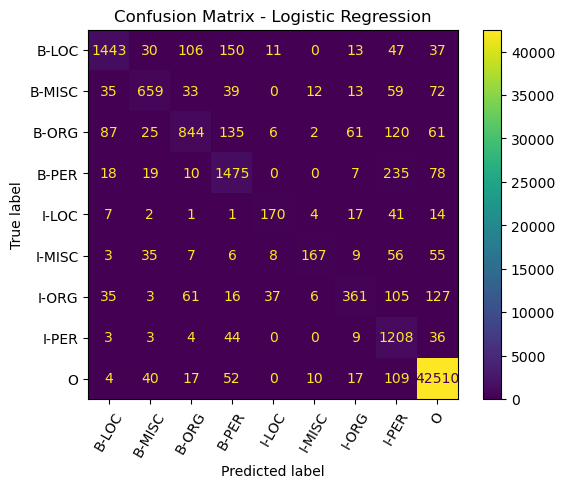

In [93]:
#Evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def read_conll_file(filename):
    """
    Reads a CoNLL file and returns a list of labels per token.
    """
    labels = []
    with open(filename, 'r', encoding='utf8') as f:
        for line in f:
            line = line.strip()
            if line == "":
                continue
            parts = line.split()
            labels.append(parts[-1])
    return labels

gold_file = devfile
pred_file = outputfile
model_name = "Logistic Regression"

print(f"\nEvaluation for {model_name}")

#Read labels
y_true = read_conll_file(gold_file)
y_pred = read_conll_file(pred_file)

#classification report
print("Token-level Classification Report")
print(classification_report(y_true, y_pred, digits=4))

#Confusion matrix
labels = sorted(list(set(y_true + y_pred)))
cm = confusion_matrix(y_true, y_pred, labels=labels)

print("Confusion Matrix")
print("Labels:", labels)
print(cm)

# Visualize 
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
display.plot(xticks_rotation=60)
plt.title(f"Confusion Matrix - {model_name}")
plt.show()


### (**optional**) 2.4.2 Convert to a python file:
- This is part is optional for now but will be required for assignment 2, so it is good practice.

Description:
- To convert the code to a python file, you should place all the relevant functions in one `.py` file.
- Add the following lines to the bottom, which ensure that if you call the function from a terminal, the lines within it will be exectued:


In [ ]:
def main(argv=None):
    """TODO fill in docstring"""

    #a very basic way for picking up commandline arguments
    if argv is None:
        argv = sys.argv
        
    #Note 1: argv[0] is the name of the python program if you run your program as: python program1.py arg1 arg2 arg3
    #Note 2: sys.argv is simple, but gets messy if you need it for anything else than basic scenarios with few arguments
    #you'll want to move to something better. e.g. argparse (easy to find online)
    
    
    #you can replace the values for these with paths to the appropriate files for now, e.g. by specifying values in argv
    #argv = ['mypython_program','','','']
    trainingfile = argv[1]
    inputfile = argv[2]
    outputfile = argv[3]
    
    training_features, gold_labels = extract_features_and_labels(trainingfile)
    ml_model, vec = create_classifier(training_features, gold_labels)
    classify_data(ml_model, vec, inputfile, outputfile)

# uncomment this when using this in a script    
if __name__ == '__main__':
    # Code below is executed when this python file is called from terminal
    main()


In [ ]:
# remember that the first element of the list is not used 
# (since this is the `python command when the args are read from sys.argv)
# make sure to complete the rest of the list assigned to args correctly
args = ['python']
main(args)